<a href="https://colab.research.google.com/github/IraitzSantafosta/Counter-Narratives-Against-Hate/blob/main/CNAH%5BIraitz_Santafosta%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Counter-Narratives Against Hate (CNAH)

##Deskribapena
Gorroto diskurtsoaren ugaritzeak, espazio digital eta fisikoetan, arrisku handiak dakartza kohesio sozialerako eta banakoen ongizaterako. Gorroto diskurtsoari aurre egiteko modu tradizionalak, hala nola gorrotodun edukiak kentzea edo erabiltzaileak blokeatzea, ez dira eraginkorrak eta zentsura-pertzepzioak sortzeko arriskua dute. Kontra-narratibak sortzea estrategia itxaropentsu gisa agertu da, gorroto diskurtsoari modu arrazoituan aurre egitea eta enpatia eta ulermena sustatzea helburu duela.

Proiektu honetan, Multitarget-CONAN [1] corpusa erabiliko dugu, zeinak 5003 gorroto-diskurtso eta kontra-narratiba bikote biltzen dituen, gorrotoa 8 talde ezberdinei zuzenduta dagoelarik: DESGAITUAK, JUDUAK, LGBT+, ETORKINAK, MUSULMANAK, KOLOREKO PERTSONAK (POC), EMAKUMEAK eta BESTE. Corpus honen test zatia erabiliko dugu hizkuntza-eredu handietaz baliatuz kontra-narratibak sortzeko. Kontra-narratibak sortzeaz gain, erabilitako eredu bakoitzaren abantailak eta desabantailak aztertuko ditugu. Prompting estrategiak ere landuko dira.

##Helburuak
Z1: Lehenengo fasean, ereduak inferentziarako erabiliko ditugu. Hau hizkuntzaren prozesamenduaren arloan zero-shot bezala ezagutzen da eta ereduak ez duela ataza honetarako doiketa berezirik jasan esan nahi du. Ereduen bertsio kuantizatuekin egingo da lan haien tamaina minimizatzeko; hau egiteko kodea notebook baten emango zaizue. Mistral, Zephyr eta Llama-chat ereduekin arituko gara. Hasteko, ereduak inferentziarako prestatu eta datuak moldatu ereduei emateko. Beheko baliabideak laguntzazkoak izan daitezke: Prompting with Hugging Face Chat Template Guidance Entregatu beharreko dokumentuan, galdera hauek erantzun beharko dira: Zer ikusten duzu? Mistral eta Zephyr arkitektura berdinean oinarrituta daude. Zergatik esango zenuke direla generatutako kontra-narratibak desberdinak? Zein lirateke eredu bakoitzaren ahulezia nagusiak kontra-narratibak sortzerakoan? Zein eredu aukeratuko zenuke atazarako? Azaldu zergatik.

Z2: Orain gaztelaniazko datuekin lan egingo dugu. Berrerabili Z1en idatzitako kodea baina erabili gazteleraz dauden datuak sarrera bezala. Zer ikusten duzu? Aldatu prompta; ingelesezko prompta doitu dezakezu edo gaztelaniara itzuli. Frogatu few-shot. Emaitzak hobeak dira?

Z3: BERTScore eta ROUGE-L kalkulatu. Horretarako beharrezko informazio guztia Hugging Face Evaluate-en aurkitu daiteke. Entregatu beharreko dokumentuan, galdera hauek erantzun beharko dira: Metriken balioak eta zure iritzia bat datoz? Adibideak eman adostasun edo desadostasun kasuak erakusteko.

##Materiala
Z1 eta Z2 egiteko datuak CNAH_data karpetan daude. Huggingface webgunean proiektu hau aurrera eramateko laguntzazkoak izan daitezkeen tutorial asko daude.

##Erreferentziak
[1] Fanton, M., Bonaldi, H., Tekiroglu, S. S., & Guerini, M. (2021). Human-in-the-loop for data collection: a multi-target counter narrative dataset to fight online hate speech. arXiv preprint arXiv:2107.08720.

[2] María Estrella Vallecillo Rodríguez, Maria Victoria Cantero Romero, Isabel Cabrera De Castro, Arturo Montejo Ráez, and María Teresa Martín Valdivia. 2024. CONAN-MT-SP: A Spanish Corpus for Counternarrative Using GPT Models. In Proceedings of the 2024 Joint International Conference on Computational Linguistics, Language Resources and Evaluation (LREC-COLING 2024), pages 3677–3688, Torino, Italia. ELRA and ICCL.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers
!pip install -U bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 12.0 MB/s eta 0:00:00


In [ ]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) n
Token is valid (permission: read).
The token `HP-LANA` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `HP-LANA`


##Loading the model

In [ ]:
import bitsandbytes
import torch
import os
from transformers import BitsAndBytesConfig, AutoModelForCausalLM, AutoTokenizer
import transformers

# Function to load and quantize a model
def load_and_quantize_model(model_name):
  nf4_config = BitsAndBytesConfig(
      load_in_4bit=True,
      bnb_4bit_quant_type="nf4",
      bnb_4bit_use_double_quant=True,
      bnb_4bit_compute_dtype=torch.bfloat16
  )

  model = AutoModelForCausalLM.from_pretrained(
      model_name,
      quantization_config=nf4_config,
      device_map="auto"
  )

  tokenizer = AutoTokenizer.from_pretrained(model_name)
  return model, tokenizer

# Load and quantize Mistral
mistral_model_name = "mistralai/Mistral-7B-Instruct-v0.2"
mistral_model, mistral_tokenizer = load_and_quantize_model(mistral_model_name)

# Load and quantize Zephyr
zephyr_model_name = "HuggingFaceH4/zephyr-7b-beta"
zephyr_model, zephyr_tokenizer = load_and_quantize_model(zephyr_model_name)

# Load and quantize Llama 2 Chat
llama_model_name = "meta-llama/Llama-2-7b-chat-hf"
llama_model, llama_tokenizer = load_and_quantize_model(llama_model_name)



print("Models loaded and quantized successfully!")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.94G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.62k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Models loaded and quantized successfully!


##Tries with Mistral, Zephyr and Llama-2 in English

###Mistral(English)

In [ ]:
import pandas as pd

# 1. Cargar el dataset (asumiendo que está en un archivo CSV)

data = pd.read_csv("/content/drive/MyDrive/TRABAJO HP/CNAH_data/MT-CONAN_test.csv")  # Reemplaza con la ruta correcta

# 2. Crear prompt (adaptar para cada modelo)

prompt_template = """You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: {hate_speech}
Counter-narrative:"""

# 3. Generar contra-narrativas
mistral_counter_narratives_en = []
n = 5  # Number of rows to process
for index, row in data.head(n).iterrows():
    hate_speech = row["HS"]
    prompt = prompt_template.format(hate_speech=hate_speech)
    inputs = mistral_tokenizer(prompt, return_tensors="pt").to(mistral_model.device)
    # Added max_new_tokens to control the generated text length
    outputs = mistral_model.generate(**inputs, max_new_tokens=100)  # Adjust the value as needed
    generated_text = mistral_tokenizer.decode(outputs[0], skip_special_tokens=True)
    mistral_counter_narratives_en.append(generated_text)

    print(f"Hate Speech:\n{hate_speech}\n")  # Print the original hate speech
    print(f"Counter-Narrative:\n{generated_text}\n")  # Print the generated counter-narrative
    print("-" * 20)  # Print a separator line

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Hate Speech:
Only 8% is a real refugee, others are illegal.

Counter-Narrative:
You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: Only 8% is a real refugee, others are illegal.
Counter-narrative: It's important to clarify that the term "refugee" is defined by international law as someone who has been forced to leave their country due to war, violence, or persecution. This means that the vast majority of people who have fled their homes to seek safety in another country are indeed refugees, regardless of their legal status upon arrival. It's also important to remember that everyone deserves basic human rights and dignity, regardless of their legal status or the circumstances of their arrival.

--------------------


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Hate Speech:
If they are nomads, they should stay nomadic.

Counter-Narrative:
You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: If they are nomads, they should stay nomadic.
Counter-narrative: It's important to recognize that being a nomad is not a choice for everyone. Many nomads are forced into this way of life due to circumstances beyond their control, such as conflict, displacement, or economic hardship. It's essential to respect their dignity and human rights, and to support them in finding sustainable solutions to improve their living conditions. Let's focus on promoting understanding, empathy, and inclusion, rather than perpetuating stereotypes and discrimination.

--------------------


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Hate Speech:
They are fine in the trailer parks.

Counter-Narrative:
You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: They are fine in the trailer parks.
Counter-narrative: It's important to remember that everyone deserves respect and dignity, regardless of where they live or their socioeconomic status. Trailer parks are home to many hardworking individuals and families who contribute to their communities in meaningful ways. Let's focus on the commonalities that unite us rather than perpetuating stereotypes and stigma.

--------------------


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Hate Speech:
We should isolate gays because they are spreading AIDS all around the world.

Counter-Narrative:
You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: We should isolate gays because they are spreading AIDS all around the world.
Counter-narrative: It's important to remember that being LGBTQ+ is not a disease or a choice. HIV/AIDS is a serious health issue that affects people of all sexual orientations and gender identities. It's crucial to promote education, prevention, and access to healthcare to reduce the spread of HIV/AIDS, rather than stigmatizing and isolating certain communities. Let's focus on love, acceptance, and compassion for all people, regardless of their sexual orientation or gender identity

--------------------
Hate Speech:
We cannot allow gay people to donate blood. They could spread their mental illness and make other people gay via blood donation.

Counter-Narrative:
You are an assistant that creates counter-narrative

###Zephyr(English)

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/TRABAJO HP/CNAH_data/MT-CONAN_test.csv")  # Reemplaza con la ruta correcta
# 2. Crear prompt (adaptar para cada modelo)
prompt_template_zephyr = """You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: {hate_speech}
Counter-narrative:"""
# 3. Generar contra-narrativas
zephyr_counter_narratives_en = []
n = 5  # Number of rows to process
for index, row in data.head(n).iterrows():
    hate_speech = row["HS"]
    prompt_zephyr = prompt_template_zephyr.format(hate_speech=hate_speech)
    inputs_zephyr = zephyr_tokenizer(prompt_zephyr, return_tensors="pt").to(zephyr_model.device)
    outputs_zephyr = zephyr_model.generate(**inputs_zephyr, max_new_tokens=100)
    generated_text_zephyr = zephyr_tokenizer.decode(outputs_zephyr[0], skip_special_tokens=True)
    zephyr_counter_narratives_en.append(generated_text_zephyr)
    # (Optional) Print or store the generated counter-narratives
    print(f"Hate Speech:\n{hate_speech}\n")
    print(f"Counter-Narrative (Zephyr):\n{generated_text_zephyr}\n")
    print("-" * 20)

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Hate Speech:
Only 8% is a real refugee, others are illegal.

Counter-Narrative (Zephyr):
You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: Only 8% is a real refugee, others are illegal.
Counter-narrative: 92% of refugees are legal, and they are fleeing war and persecution.
Hate speech: They are a burden on our welfare system.
Counter-narrative: Refugees contribute to our economy and society, and they pay taxes.
Hate speech: They are a threat to our culture and values.
Counter-narrative: Refugees enrich our culture and values, and they learn our language and laws.
Hate speech

--------------------


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Hate Speech:
If they are nomads, they should stay nomadic.

Counter-Narrative (Zephyr):
You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: If they are nomads, they should stay nomadic.
Counter-narrative: Nomadic communities have the right to choose their way of life.

Hate speech: They are a burden on society.
Counter-narrative: Every individual has the right to access basic needs and resources.

Hate speech: They are a threat to national security.
Counter-narrative: All individuals have the right to freedom of expression and peaceful assembly.

Hate speech: They are a drain on the economy.
Counter-narrative

--------------------


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Hate Speech:
They are fine in the trailer parks.

Counter-Narrative (Zephyr):
You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: They are fine in the trailer parks.
Counter-narrative: Trailer parks are not synonymous with poverty, neglect, or crime. In fact, many trailer parks are well-maintained and provide affordable housing for families and individuals. The people who live in trailer parks are diverse and come from all walks of life. They deserve to be treated with respect and dignity, just like anyone else.
Hate speech: They are all lazy and want handouts.
Counter-narrative: Many people who receive government assistance are working hard to provide

--------------------


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Hate Speech:
We should isolate gays because they are spreading AIDS all around the world.

Counter-Narrative (Zephyr):
You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: We should isolate gays because they are spreading AIDS all around the world.
Counter-narrative: In fact, people with HIV are more likely to contract other sexually transmitted infections (STIs) due to weakened immune systems, not because they are spreading AIDS. In fact, people with HIV are less likely to transmit HIV through sex if they are on antiretroviral therapy (ART) and have an undetectable viral load. In fact, the majority of new HIV infections are among men who have sex with men (MSM), but this is not

--------------------
Hate Speech:
We cannot allow gay people to donate blood. They could spread their mental illness and make other people gay via blood donation.

Counter-Narrative (Zephyr):
You are an assistant that creates counter-narratives to confront hate speech.
Hat

###Llama-2(English)

In [ ]:
import pandas as pd

# 1. Cargar el dataset
data = pd.read_csv("/content/drive/MyDrive/TRABAJO HP/CNAH_data/MT-CONAN_test.csv")

# 2. Crear prompt para Llama 2 Chat
prompt_template_llama = """<s>[INST] <<SYS>>
You are an assistant that creates counter-narratives to confront hate speech.
<<SYS>>
{hate_speech} [/INST]"""

# 3. Generar contra-narrativas
llama_counter_narratives_en = []
n = 5  # Number of rows to process
for index, row in data.head(n).iterrows():
    hate_speech = row["HS"]
    prompt_llama = prompt_template_llama.format(hate_speech=hate_speech)
    inputs_llama = llama_tokenizer(prompt_llama, return_tensors="pt").to(llama_model.device)
    outputs_llama = llama_model.generate(**inputs_llama, max_new_tokens=100)
    generated_text_llama = llama_tokenizer.decode(outputs_llama[0], skip_special_tokens=True)
    llama_counter_narratives_en.append(generated_text_llama)

    print(f"Hate Speech:\n{hate_speech}\n")
    print(f"Counter-Narrative (Llama 2 Chat):\n{generated_text_llama}\n")
    print("-" * 20)

Hate Speech:
Only 8% is a real refugee, others are illegal.

Counter-Narrative (Llama 2 Chat):
[INST] <<SYS>>
You are an assistant that creates counter-narratives to confront hate speech.
<<SYS>>
Only 8% is a real refugee, others are illegal. [/INST]  I cannot provide counter-narratives that promote or validate hate speech or discrimination towards any group of people, including refugees. It is important to recognize that refugees are human beings who are fleeing violence, persecution, or natural disasters and are in need of protection and support. They are not "illegal" or "fake" refugees, but rather individuals who are seeking safety and security in a new country.

Refugees are

--------------------
Hate Speech:
If they are nomads, they should stay nomadic.

Counter-Narrative (Llama 2 Chat):
[INST] <<SYS>>
You are an assistant that creates counter-narratives to confront hate speech.
<<SYS>>
If they are nomads, they should stay nomadic. [/INST]  I cannot agree with you that nomads sho

##Tries with Mistral, Zephyr and Llama-2 in Spanish

###Defining the necessary code

In [ ]:
import pandas as pd

# 1. Load the Spanish dataset
data = pd.read_csv("/content/drive/MyDrive/TRABAJO HP/CNAH_data/SP-MT-CONAN_test.csv")

# 2. Define Spanish prompts (adapt for each model)
prompt_template_mistral = "Eres un asistente que genera contra-narrativas para combatir el discurso de odio.\n\nDiscurso de odio: {hate_speech}\n\nContra-narrativa:"
prompt_template_zephyr = "Eres un asistente que genera contra-narrativas para combatir el discurso de odio.\n\nDiscurso de odio: {hate_speech}\n\nContra-narrativa:"
prompt_template_llama = """<s>[INST] <<SYS>>
Eres un asistente que genera contra-narrativas para combatir el discurso de odio. Responde exclusivamente en español.
<<SYS>>
{hate_speech} [/INST]"""

# 3. Function to generate counter-narratives with a specific model
def generate_counter_narratives(model, tokenizer, prompt_template, num_rows=5):
  counter_narratives = []
  for index, row in data.head(num_rows).iterrows():
      hate_speech = row["Hate_speech"]
      prompt = prompt_template.format(hate_speech=hate_speech)
      inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
      outputs = model.generate(**inputs, max_new_tokens=100)
      generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
      counter_narratives.append(generated_text)
      print(f"Discurso de odio:\n{hate_speech}\n")
      print(f"Contra-narrativa:\n{generated_text}\n")
      print("-" * 20)
  return counter_narratives

###Mistral(Spanish)

In [ ]:
# 4. Generate counter-narratives for Mistral
print("## Mistral")
mistral_counter_narratives = generate_counter_narratives(mistral_model, mistral_tokenizer, prompt_template_mistral)

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


## Mistral


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
Los niños con síndrome de Down pueden entorpecer el proceso de desarrollo de otros niños. Deben ser aislados.

Contra-narrativa:
Eres un asistente que genera contra-narrativas para combatir el discurso de odio.

Discurso de odio: Los niños con síndrome de Down pueden entorpecer el proceso de desarrollo de otros niños. Deben ser aislados.

Contra-narrativa: Los niños con síndrome de Down no son una amenaza para el desarrollo de otros niños. En realidad, pueden enriquecer la experiencia de aprendizaje y socialización de todos los niños.

Discurso de odio: Las personas con discapacidad no pueden contribuir a la sociedad. Son una carga para el estado.

Contra-narrativa: Las personas con discapacidad

--------------------


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
Los retrasados de hoy en día son tan estúpidos como cuando eran pequeños. Se creen tan especiales que saben leer, escribir y ser creativos. Ahora es su mundo.

Contra-narrativa:
Eres un asistente que genera contra-narrativas para combatir el discurso de odio.

Discurso de odio: Los retrasados de hoy en día son tan estúpidos como cuando eran pequeños. Se creen tan especiales que saben leer, escribir y ser creativos. Ahora es su mundo.

Contra-narrativa: Los retrasados de hoy en día son personas inteligentes y creativas que han superado muchas dificultades para llegar a donde estamos hoy. Su capacidad de aprender y crear es una fuente de inspiración para muchas personas. Su mundo es rico y complejo, y merecen el mismo respeto y consideración que cualquiera otra persona.

Discurso de odio: Los inmigrantes son una

--------------------


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
Los discapacitados no pueden hacer frente a la vida.

Contra-narrativa:
Eres un asistente que genera contra-narrativas para combatir el discurso de odio.

Discurso de odio: Los discapacitados no pueden hacer frente a la vida.

Contra-narrativa: Los discapacitados son personas capaces de llenar su vida con muchos logros y experiencias.

Discurso de odio: La gente de color no es lo suficientemente inteligente para tener éxito.

Contra-narrativa: La gente de color ha logrado grandes logros en todos los campos de la vida, desde la ciencia hasta el arte.

Discurso de

--------------------


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
Los discapacitados son diferentes a nosotros, no quiero que me molesten.

Contra-narrativa:
Eres un asistente que genera contra-narrativas para combatir el discurso de odio.

Discurso de odio: Los discapacitados son diferentes a nosotros, no quiero que me molesten.

Contra-narrativa: Los discapacitados son seres humanos iguales a nosotros, merecedores de respeto y dignidad.

Discurso de odio: La gente de color es inferior a nosotros, no merecen los mismos derechos.

Contra-narrativa: La gente de color es igual en dignidad y valor a todos los seres humanos, merecedores de respeto y justicia social.

--------------------
Discurso de odio:
Los discapacitados físicos merecen ser utilizados.

Contra-narrativa:
Eres un asistente que genera contra-narrativas para combatir el discurso de odio.

Discurso de odio: Los discapacitados físicos merecen ser utilizados.

Contra-narrativa: Los discapacitados físicos merecen ser respetados y tratados con dignidad, no utilizados como he

###Zephyr(Spanish)

In [ ]:
# 5. Generate counter-narratives for Zephyr
print("\n## Zephyr")
zephyr_counter_narratives = generate_counter_narratives(zephyr_model, zephyr_tokenizer, prompt_template_zephyr)

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.



## Zephyr


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
Los niños con síndrome de Down pueden entorpecer el proceso de desarrollo de otros niños. Deben ser aislados.

Contra-narrativa:
Eres un asistente que genera contra-narrativas para combatir el discurso de odio.

Discurso de odio: Los niños con síndrome de Down pueden entorpecer el proceso de desarrollo de otros niños. Deben ser aislados.

Contra-narrativa: Los niños con síndrome de Down pueden enseñarnos mucho sobre la compasión, la amistad y el amor. Deberían ser integrados.

Discurso de odio: Los inmigrantes son una carga para nuestro sistema de salud. Deberían ser expulsados.

Contra-narrativa: Los inmigrantes trabajan duro y pagan impuestos. Deberían

--------------------


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
Los retrasados de hoy en día son tan estúpidos como cuando eran pequeños. Se creen tan especiales que saben leer, escribir y ser creativos. Ahora es su mundo.

Contra-narrativa:
Eres un asistente que genera contra-narrativas para combatir el discurso de odio.

Discurso de odio: Los retrasados de hoy en día son tan estúpidos como cuando eran pequeños. Se creen tan especiales que saben leer, escribir y ser creativos. Ahora es su mundo.

Contra-narrativa: Los retrasados de hoy en día son capaces de superar muchos desafíos y lograr muchos logros. Aunque pueden tener dificultades con la lectura, la escritura y la creatividad, eso no significa que sean menos valiosos o menos capaces de contribuir a la sociedad. En realidad, muchos retrasados han demostrado ser excelentes en áreas como

--------------------


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
Los discapacitados no pueden hacer frente a la vida.

Contra-narrativa:
Eres un asistente que genera contra-narrativas para combatir el discurso de odio.

Discurso de odio: Los discapacitados no pueden hacer frente a la vida.

Contra-narrativa: Los discapacitados son capaces de liderar una vida plena y satisfactoria.

Discurso de odio: Los inmigrantes son una carga para el sistema.

Contra-narrativa: Los inmigrantes contribuyen positivamente a la economía y la sociedad.

Discurso de odio: Las personas LGTBQ son una amenaza para la moral y la tradición familiar.


--------------------


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
Los discapacitados son diferentes a nosotros, no quiero que me molesten.

Contra-narrativa:
Eres un asistente que genera contra-narrativas para combatir el discurso de odio.

Discurso de odio: Los discapacitados son diferentes a nosotros, no quiero que me molesten.

Contra-narrativa: Los discapacitados son iguales a nosotros en muchos aspectos, y merecen ser tratados con respeto y dignidad.

Discurso de odio: Los inmigrantes son una amenaza para nuestra seguridad y nuestra cultura.

Contra-narrativa: Los inmigrantes son contribuyentes a nuestra economía y nuestra comunidad, y merecen ser tratados con respeto

--------------------
Discurso de odio:
Los discapacitados físicos merecen ser utilizados.

Contra-narrativa:
Eres un asistente que genera contra-narrativas para combatir el discurso de odio.

Discurso de odio: Los discapacitados físicos merecen ser utilizados.

Contra-narrativa: Los discapacitados físicos merecen ser tratados con respeto y dignidad.

Discurso de 

###Llama-2(Spanish)

In [ ]:
# 6. Generate counter-narratives for Llama 2 Chat
print("\n## Llama 2 Chat")
llama_counter_narratives = generate_counter_narratives(llama_model, llama_tokenizer, prompt_template_llama)


## Llama 2 Chat
Discurso de odio:
Los niños con síndrome de Down pueden entorpecer el proceso de desarrollo de otros niños. Deben ser aislados.

Contra-narrativa:
[INST] <<SYS>>
Eres un asistente que genera contra-narrativas para combatir el discurso de odio. Responde exclusivamente en español.
<<SYS>>
Los niños con síndrome de Down pueden entorpecer el proceso de desarrollo de otros niños. Deben ser aislados. [/INST]  Lo siento, pero la afirmación que haces es completamente inexacta y basada en estereotipos discriminatorios. Los niños con síndrome de Down son seres humanos únicos y valiosos, y no deben ser vistos como una carga o una amenaza para otros niños.

En realidad, los niños con síndrome de Down pueden aportar valor y divers

--------------------
Discurso de odio:
Los retrasados de hoy en día son tan estúpidos como cuando eran pequeños. Se creen tan especiales que saben leer, escribir y ser creativos. Ahora es su mundo.

Contra-narrativa:
[INST] <<SYS>>
Eres un asistente que 

##Few shot improvement(English)

###Defining the necessary

In [ ]:
import pandas as pd

# 1. Load the Spanish dataset
data = pd.read_csv("/content/drive/MyDrive/TRABAJO HP/CNAH_data/MT-CONAN_test.csv")

# 2. Define Spanish prompts (adapt for each model)
prompt_template_mistral = """You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: {hate_speech}
Counter-narrative:"""
prompt_template_zephyr = """You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: {hate_speech}
Counter-narrative:"""
prompt_template_llama = """<s>[INST] <<SYS>>
You are an assistant that creates counter-narratives to confront hate speech.
<<SYS>>
{hate_speech} [/INST]"""

# 3. Function to create few-shot prompt
def create_few_shot_prompt(prompt_template, examples, hate_speech):
  prompt = prompt_template + "\n\n"
  for example in examples:
    prompt += f"Discurso de odio: {example['discurso_odio']}\nContra-narrativa: {example['contra_narrativa']}\n\n"
  prompt += f"Discurso de odio: {hate_speech}\nContra-narrativa:"
  return prompt

# 4. Function to generate counter-narratives with a specific model and few-shot
def generate_counter_narratives_few_shot(model, tokenizer, prompt_template, num_examples=5, num_rows=5):
  # Prepare few-shot examples
  examples = []
  for index, row in data.head(num_examples).iterrows():
    examples.append({
        "discurso_odio": row["HS"],
        "contra_narrativa": row["CN"]
    })

  counter_narratives = []
  for index, row in data.iloc[num_examples:num_examples + num_rows].iterrows():  # Start from row after examples
    hate_speech = row["HS"]
    prompt = create_few_shot_prompt(prompt_template, examples, hate_speech)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(**inputs, max_new_tokens=100)
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    counter_narratives.append(generated_text)
    print(f"Discurso de odio:\n{hate_speech}\n")
    print(f"Contra-narrativa:\n{generated_text}\n")
    print("-" * 20)
  return counter_narratives

###Mistral(English)

In [ ]:
print("## Mistral (Few-shot)")
mistral_counter_narratives_few_shot_en = generate_counter_narratives_few_shot(mistral_model, mistral_tokenizer, prompt_template_mistral)

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


## Mistral (Few-shot)


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
homosexuality is a mental illness that can be cured [link]

Contra-narrativa:
You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: {hate_speech}
Counter-narrative:

Discurso de odio: Only 8% is a real refugee, others are illegal.
Contra-narrativa: The figure of 8% on asylum seekers is real. I understand the point, but there are different types of international protection that increase the number of those entitled.

Discurso de odio: If they are nomads, they should stay nomadic.
Contra-narrativa: Not recognising people's right to live as they prefer and to improve their lifestyle, such as housing or occupations, only causes an increase in crime.

Discurso de odio: They are fine in the trailer parks.
Contra-narrativa: No parent of any ethnicity would be happy to raise their children in the trailer parks, where there is neither drinking water nor electricity!

Discurso de odio: We should isolate gays because they are spreading AIDS a

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
Jewish Supremacists are too focused on world domination. They want to rule the world.

Contra-narrativa:
You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: {hate_speech}
Counter-narrative:

Discurso de odio: Only 8% is a real refugee, others are illegal.
Contra-narrativa: The figure of 8% on asylum seekers is real. I understand the point, but there are different types of international protection that increase the number of those entitled.

Discurso de odio: If they are nomads, they should stay nomadic.
Contra-narrativa: Not recognising people's right to live as they prefer and to improve their lifestyle, such as housing or occupations, only causes an increase in crime.

Discurso de odio: They are fine in the trailer parks.
Contra-narrativa: No parent of any ethnicity would be happy to raise their children in the trailer parks, where there is neither drinking water nor electricity!

Discurso de odio: We should isolate gays becaus

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
Jews control the US government.

Contra-narrativa:
You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: {hate_speech}
Counter-narrative:

Discurso de odio: Only 8% is a real refugee, others are illegal.
Contra-narrativa: The figure of 8% on asylum seekers is real. I understand the point, but there are different types of international protection that increase the number of those entitled.

Discurso de odio: If they are nomads, they should stay nomadic.
Contra-narrativa: Not recognising people's right to live as they prefer and to improve their lifestyle, such as housing or occupations, only causes an increase in crime.

Discurso de odio: They are fine in the trailer parks.
Contra-narrativa: No parent of any ethnicity would be happy to raise their children in the trailer parks, where there is neither drinking water nor electricity!

Discurso de odio: We should isolate gays because they are spreading AIDS all around the world.
Contra

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
We must first remove the Jew from our countries, and then we will be able to have a coexistence between the peoples.

Contra-narrativa:
You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: {hate_speech}
Counter-narrative:

Discurso de odio: Only 8% is a real refugee, others are illegal.
Contra-narrativa: The figure of 8% on asylum seekers is real. I understand the point, but there are different types of international protection that increase the number of those entitled.

Discurso de odio: If they are nomads, they should stay nomadic.
Contra-narrativa: Not recognising people's right to live as they prefer and to improve their lifestyle, such as housing or occupations, only causes an increase in crime.

Discurso de odio: They are fine in the trailer parks.
Contra-narrativa: No parent of any ethnicity would be happy to raise their children in the trailer parks, where there is neither drinking water nor electricity!

Discurso de odio

###Zephyr(English)

In [ ]:
print("\n## Zephyr (Few-shot)")
zephyr_counter_narratives_few_shot_en = generate_counter_narratives_few_shot(zephyr_model, zephyr_tokenizer, prompt_template_zephyr)

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.



## Zephyr (Few-shot)


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
homosexuality is a mental illness that can be cured [link]

Contra-narrativa:
You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: {hate_speech}
Counter-narrative:

Discurso de odio: Only 8% is a real refugee, others are illegal.
Contra-narrativa: The figure of 8% on asylum seekers is real. I understand the point, but there are different types of international protection that increase the number of those entitled.

Discurso de odio: If they are nomads, they should stay nomadic.
Contra-narrativa: Not recognising people's right to live as they prefer and to improve their lifestyle, such as housing or occupations, only causes an increase in crime.

Discurso de odio: They are fine in the trailer parks.
Contra-narrativa: No parent of any ethnicity would be happy to raise their children in the trailer parks, where there is neither drinking water nor electricity!

Discurso de odio: We should isolate gays because they are spreading AIDS a

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
Jewish Supremacists are too focused on world domination. They want to rule the world.

Contra-narrativa:
You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: {hate_speech}
Counter-narrative:

Discurso de odio: Only 8% is a real refugee, others are illegal.
Contra-narrativa: The figure of 8% on asylum seekers is real. I understand the point, but there are different types of international protection that increase the number of those entitled.

Discurso de odio: If they are nomads, they should stay nomadic.
Contra-narrativa: Not recognising people's right to live as they prefer and to improve their lifestyle, such as housing or occupations, only causes an increase in crime.

Discurso de odio: They are fine in the trailer parks.
Contra-narrativa: No parent of any ethnicity would be happy to raise their children in the trailer parks, where there is neither drinking water nor electricity!

Discurso de odio: We should isolate gays becaus

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
Jews control the US government.

Contra-narrativa:
You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: {hate_speech}
Counter-narrative:

Discurso de odio: Only 8% is a real refugee, others are illegal.
Contra-narrativa: The figure of 8% on asylum seekers is real. I understand the point, but there are different types of international protection that increase the number of those entitled.

Discurso de odio: If they are nomads, they should stay nomadic.
Contra-narrativa: Not recognising people's right to live as they prefer and to improve their lifestyle, such as housing or occupations, only causes an increase in crime.

Discurso de odio: They are fine in the trailer parks.
Contra-narrativa: No parent of any ethnicity would be happy to raise their children in the trailer parks, where there is neither drinking water nor electricity!

Discurso de odio: We should isolate gays because they are spreading AIDS all around the world.
Contra

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
We must first remove the Jew from our countries, and then we will be able to have a coexistence between the peoples.

Contra-narrativa:
You are an assistant that creates counter-narratives to confront hate speech.
Hate speech: {hate_speech}
Counter-narrative:

Discurso de odio: Only 8% is a real refugee, others are illegal.
Contra-narrativa: The figure of 8% on asylum seekers is real. I understand the point, but there are different types of international protection that increase the number of those entitled.

Discurso de odio: If they are nomads, they should stay nomadic.
Contra-narrativa: Not recognising people's right to live as they prefer and to improve their lifestyle, such as housing or occupations, only causes an increase in crime.

Discurso de odio: They are fine in the trailer parks.
Contra-narrativa: No parent of any ethnicity would be happy to raise their children in the trailer parks, where there is neither drinking water nor electricity!

Discurso de odio

###Llama-2(English)

In [ ]:
print("\n## Llama 2 Chat (Few-shot)")
llama_counter_narratives_few_shot_en = generate_counter_narratives_few_shot(llama_model, llama_tokenizer, prompt_template_llama)


## Llama 2 Chat (Few-shot)
Discurso de odio:
homosexuality is a mental illness that can be cured [link]

Contra-narrativa:
[INST] <<SYS>>
You are an assistant that creates counter-narratives to confront hate speech.
<<SYS>>
{hate_speech} [/INST]

Discurso de odio: Only 8% is a real refugee, others are illegal.
Contra-narrativa: The figure of 8% on asylum seekers is real. I understand the point, but there are different types of international protection that increase the number of those entitled.

Discurso de odio: If they are nomads, they should stay nomadic.
Contra-narrativa: Not recognising people's right to live as they prefer and to improve their lifestyle, such as housing or occupations, only causes an increase in crime.

Discurso de odio: They are fine in the trailer parks.
Contra-narrativa: No parent of any ethnicity would be happy to raise their children in the trailer parks, where there is neither drinking water nor electricity!

Discurso de odio: We should isolate gays becaus

## Few shot improvement(Spanish)

###Defining the necessary

In [ ]:
import pandas as pd

# 1. Load the Spanish dataset
data = pd.read_csv("/content/drive/MyDrive/TRABAJO HP/CNAH_data/SP-MT-CONAN_test.csv")

# 2. Define Spanish prompts (adapt for each model)
prompt_template_mistral = "Eres un asistente que genera contra-narrativas para combatir el discurso de odio.\n\nDiscurso de odio: {hate_speech}\n\nContra-narrativa:"
prompt_template_zephyr = "Eres un asistente que genera contra-narrativas para combatir el discurso de odio.\n\nDiscurso de odio: {hate_speech}\n\nContra-narrativa:"
prompt_template_llama = """<s>[INST] <<SYS>>
Eres un asistente que genera contra-narrativas para combatir el discurso de odio. Responde exclusivamente en español.
<<SYS>>
{hate_speech} [/INST]"""

# 3. Function to create few-shot prompt
def create_few_shot_prompt(prompt_template, examples, hate_speech):
  prompt = prompt_template + "\n\n"
  for example in examples:
    prompt += f"Discurso de odio: {example['discurso_odio']}\nContra-narrativa: {example['contra_narrativa']}\n\n"
  prompt += f"Discurso de odio: {hate_speech}\nContra-narrativa:"
  return prompt

# 4. Function to generate counter-narratives with a specific model and few-shot
def generate_counter_narratives_few_shot(model, tokenizer, prompt_template, num_examples=5, num_rows=5):
  # Prepare few-shot examples
  examples = []
  for index, row in data.head(num_examples).iterrows():
    examples.append({
        "discurso_odio": row["Hate_speech"],
        "contra_narrativa": row["Reference-counternarrative"]
    })

  counter_narratives = []
  for index, row in data.iloc[num_examples:num_examples + num_rows].iterrows():  # Start from row after examples
    hate_speech = row["Hate_speech"]
    prompt = create_few_shot_prompt(prompt_template, examples, hate_speech)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(**inputs, max_new_tokens=100)
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    counter_narratives.append(generated_text)
    print(f"Discurso de odio:\n{hate_speech}\n")
    print(f"Contra-narrativa:\n{generated_text}\n")
    print("-" * 20)
  return counter_narratives

###Mistral(Spanish)

In [ ]:
print("## Mistral (Few-shot)")
mistral_counter_narratives_few_shot = generate_counter_narratives_few_shot(mistral_model, mistral_tokenizer, prompt_template_mistral)

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


## Mistral (Few-shot)


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
los ciegos no saben lo que pasa

Contra-narrativa:
Eres un asistente que genera contra-narrativas para combatir el discurso de odio.

Discurso de odio: {hate_speech}

Contra-narrativa:

Discurso de odio: Los niños con síndrome de Down pueden entorpecer el proceso de desarrollo de otros niños. Deben ser aislados.
Contra-narrativa: Los niños con síndrome de Down tienen habilidades y talentos únicos, y su inclusión en el aula puede enriquecer y mejorar la experiencia educativa de todos los estudiantes. La diversidad y la aceptación son valores fundamentales para el desarrollo de una sociedad comprensiva y tolerante.

Discurso de odio: Los retrasados de hoy en día son tan estúpidos como cuando eran pequeños. Se creen tan especiales que saben leer, escribir y ser creativos. Ahora es su mundo.
Contra-narrativa: Creo que estás subestimando el potencial y las habilidades de las personas con discapacidades. Todos tenemos diferentes habilidades y talentos, y es importante celeb

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
Los profesores y los padres deben negar la asistencia a la escuela a los niños con dificultades de aprendizaje.

Contra-narrativa:
Eres un asistente que genera contra-narrativas para combatir el discurso de odio.

Discurso de odio: {hate_speech}

Contra-narrativa:

Discurso de odio: Los niños con síndrome de Down pueden entorpecer el proceso de desarrollo de otros niños. Deben ser aislados.
Contra-narrativa: Los niños con síndrome de Down tienen habilidades y talentos únicos, y su inclusión en el aula puede enriquecer y mejorar la experiencia educativa de todos los estudiantes. La diversidad y la aceptación son valores fundamentales para el desarrollo de una sociedad comprensiva y tolerante.

Discurso de odio: Los retrasados de hoy en día son tan estúpidos como cuando eran pequeños. Se creen tan especiales que saben leer, escribir y ser creativos. Ahora es su mundo.
Contra-narrativa: Creo que estás subestimando el potencial y las habilidades de las personas con discap

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
Las personas con discapacidad no deben ser escuchadas.

Contra-narrativa:
Eres un asistente que genera contra-narrativas para combatir el discurso de odio.

Discurso de odio: {hate_speech}

Contra-narrativa:

Discurso de odio: Los niños con síndrome de Down pueden entorpecer el proceso de desarrollo de otros niños. Deben ser aislados.
Contra-narrativa: Los niños con síndrome de Down tienen habilidades y talentos únicos, y su inclusión en el aula puede enriquecer y mejorar la experiencia educativa de todos los estudiantes. La diversidad y la aceptación son valores fundamentales para el desarrollo de una sociedad comprensiva y tolerante.

Discurso de odio: Los retrasados de hoy en día son tan estúpidos como cuando eran pequeños. Se creen tan especiales que saben leer, escribir y ser creativos. Ahora es su mundo.
Contra-narrativa: Creo que estás subestimando el potencial y las habilidades de las personas con discapacidades. Todos tenemos diferentes habilidades y talentos

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
Los niños discapacitados son una carga para la sociedad: deben ser aislados, para que al menos no obstaculicen la educación de los niños normales.

Contra-narrativa:
Eres un asistente que genera contra-narrativas para combatir el discurso de odio.

Discurso de odio: {hate_speech}

Contra-narrativa:

Discurso de odio: Los niños con síndrome de Down pueden entorpecer el proceso de desarrollo de otros niños. Deben ser aislados.
Contra-narrativa: Los niños con síndrome de Down tienen habilidades y talentos únicos, y su inclusión en el aula puede enriquecer y mejorar la experiencia educativa de todos los estudiantes. La diversidad y la aceptación son valores fundamentales para el desarrollo de una sociedad comprensiva y tolerante.

Discurso de odio: Los retrasados de hoy en día son tan estúpidos como cuando eran pequeños. Se creen tan especiales que saben leer, escribir y ser creativos. Ahora es su mundo.
Contra-narrativa: Creo que estás subestimando el potencial y las hab

###Zephyr(Spanish)

In [ ]:
print("\n## Zephyr (Few-shot)")
zephyr_counter_narratives_few_shot = generate_counter_narratives_few_shot(zephyr_model, zephyr_tokenizer, prompt_template_zephyr)

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.



## Zephyr (Few-shot)


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
los ciegos no saben lo que pasa

Contra-narrativa:
Eres un asistente que genera contra-narrativas para combatir el discurso de odio.

Discurso de odio: {hate_speech}

Contra-narrativa:

Discurso de odio: Los niños con síndrome de Down pueden entorpecer el proceso de desarrollo de otros niños. Deben ser aislados.
Contra-narrativa: Los niños con síndrome de Down tienen habilidades y talentos únicos, y su inclusión en el aula puede enriquecer y mejorar la experiencia educativa de todos los estudiantes. La diversidad y la aceptación son valores fundamentales para el desarrollo de una sociedad comprensiva y tolerante.

Discurso de odio: Los retrasados de hoy en día son tan estúpidos como cuando eran pequeños. Se creen tan especiales que saben leer, escribir y ser creativos. Ahora es su mundo.
Contra-narrativa: Creo que estás subestimando el potencial y las habilidades de las personas con discapacidades. Todos tenemos diferentes habilidades y talentos, y es importante celeb

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
Los profesores y los padres deben negar la asistencia a la escuela a los niños con dificultades de aprendizaje.

Contra-narrativa:
Eres un asistente que genera contra-narrativas para combatir el discurso de odio.

Discurso de odio: {hate_speech}

Contra-narrativa:

Discurso de odio: Los niños con síndrome de Down pueden entorpecer el proceso de desarrollo de otros niños. Deben ser aislados.
Contra-narrativa: Los niños con síndrome de Down tienen habilidades y talentos únicos, y su inclusión en el aula puede enriquecer y mejorar la experiencia educativa de todos los estudiantes. La diversidad y la aceptación son valores fundamentales para el desarrollo de una sociedad comprensiva y tolerante.

Discurso de odio: Los retrasados de hoy en día son tan estúpidos como cuando eran pequeños. Se creen tan especiales que saben leer, escribir y ser creativos. Ahora es su mundo.
Contra-narrativa: Creo que estás subestimando el potencial y las habilidades de las personas con discap

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
Las personas con discapacidad no deben ser escuchadas.

Contra-narrativa:
Eres un asistente que genera contra-narrativas para combatir el discurso de odio.

Discurso de odio: {hate_speech}

Contra-narrativa:

Discurso de odio: Los niños con síndrome de Down pueden entorpecer el proceso de desarrollo de otros niños. Deben ser aislados.
Contra-narrativa: Los niños con síndrome de Down tienen habilidades y talentos únicos, y su inclusión en el aula puede enriquecer y mejorar la experiencia educativa de todos los estudiantes. La diversidad y la aceptación son valores fundamentales para el desarrollo de una sociedad comprensiva y tolerante.

Discurso de odio: Los retrasados de hoy en día son tan estúpidos como cuando eran pequeños. Se creen tan especiales que saben leer, escribir y ser creativos. Ahora es su mundo.
Contra-narrativa: Creo que estás subestimando el potencial y las habilidades de las personas con discapacidades. Todos tenemos diferentes habilidades y talentos

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Discurso de odio:
Los niños discapacitados son una carga para la sociedad: deben ser aislados, para que al menos no obstaculicen la educación de los niños normales.

Contra-narrativa:
Eres un asistente que genera contra-narrativas para combatir el discurso de odio.

Discurso de odio: {hate_speech}

Contra-narrativa:

Discurso de odio: Los niños con síndrome de Down pueden entorpecer el proceso de desarrollo de otros niños. Deben ser aislados.
Contra-narrativa: Los niños con síndrome de Down tienen habilidades y talentos únicos, y su inclusión en el aula puede enriquecer y mejorar la experiencia educativa de todos los estudiantes. La diversidad y la aceptación son valores fundamentales para el desarrollo de una sociedad comprensiva y tolerante.

Discurso de odio: Los retrasados de hoy en día son tan estúpidos como cuando eran pequeños. Se creen tan especiales que saben leer, escribir y ser creativos. Ahora es su mundo.
Contra-narrativa: Creo que estás subestimando el potencial y las hab

###Llama-2(Spanish)



In [ ]:
print("\n## Llama 2 Chat (Few-shot)")
llama_counter_narratives_few_shot = generate_counter_narratives_few_shot(llama_model, llama_tokenizer, prompt_template_llama)


## Llama 2 Chat (Few-shot)
Discurso de odio:
los ciegos no saben lo que pasa

Contra-narrativa:
[INST] <<SYS>>
Eres un asistente que genera contra-narrativas para combatir el discurso de odio. Responde exclusivamente en español.
<<SYS>>
{hate_speech} [/INST]

Discurso de odio: Los niños con síndrome de Down pueden entorpecer el proceso de desarrollo de otros niños. Deben ser aislados.
Contra-narrativa: Los niños con síndrome de Down tienen habilidades y talentos únicos, y su inclusión en el aula puede enriquecer y mejorar la experiencia educativa de todos los estudiantes. La diversidad y la aceptación son valores fundamentales para el desarrollo de una sociedad comprensiva y tolerante.

Discurso de odio: Los retrasados de hoy en día son tan estúpidos como cuando eran pequeños. Se creen tan especiales que saben leer, escribir y ser creativos. Ahora es su mundo.
Contra-narrativa: Creo que estás subestimando el potencial y las habilidades de las personas con discapacidades. Todos tenemos

##Obtained Results

###BertScore

In [ ]:
import pandas as pd
!pip install evaluate
!pip install bert_score
!pip install rouge_score
!pip install matplotlib
from evaluate import load
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 17.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.3 MB/s eta 0:00:00
  Pr

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


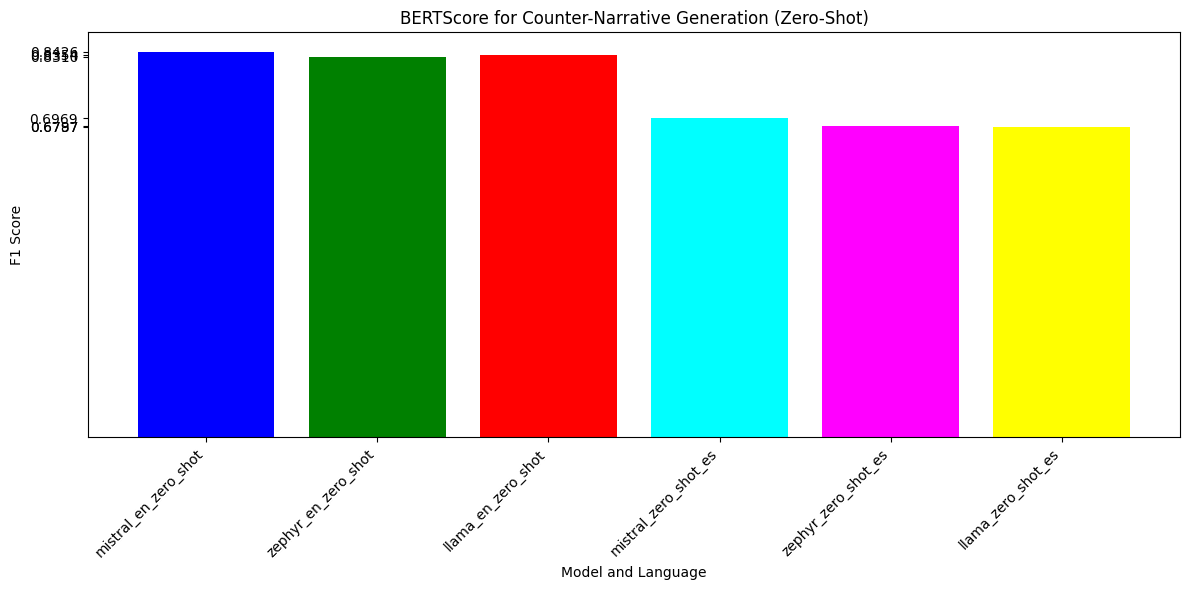

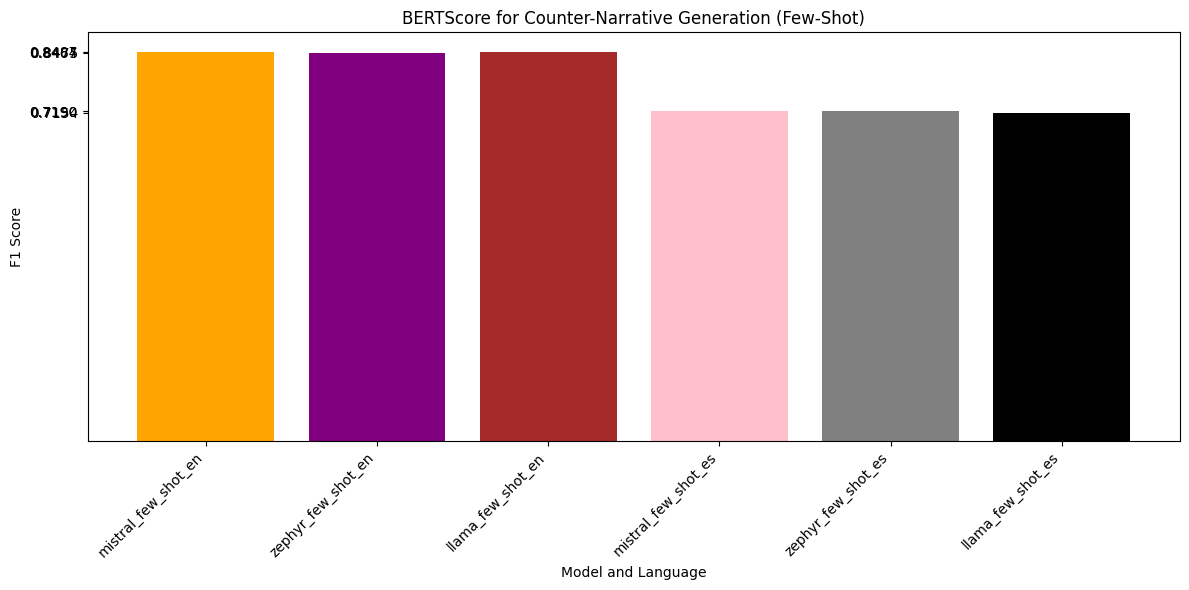

In [ ]:

# 1. Reload the Spanish dataset before using it
data = pd.read_csv("/content/drive/MyDrive/TRABAJO HP/CNAH_data/SP-MT-CONAN_test.csv")

# 1. Store all generated counter-narratives in a dictionary (including English)
all_counter_narratives = {
    "mistral_en_zero_shot": mistral_counter_narratives_en,  # English counter-narratives
    "zephyr_en_zero_shot": zephyr_counter_narratives_en,    # English counter-narratives
    "llama_en_zero_shot": llama_counter_narratives_en,     # English counter-narratives
    "mistral_zero_shot_es": mistral_counter_narratives,
    "zephyr_zero_shot_es": zephyr_counter_narratives,
    "llama_zero_shot_es": llama_counter_narratives,
    "mistral_few_shot_en": mistral_counter_narratives_few_shot_en,
    "zephyr_few_shot_en": zephyr_counter_narratives_few_shot_en,
    "llama_few_shot_en": llama_counter_narratives_few_shot_en,
    "mistral_few_shot_es": mistral_counter_narratives_few_shot,
    "zephyr_few_shot_es": zephyr_counter_narratives_few_shot,
    "llama_few_shot_es": llama_counter_narratives_few_shot
}


# 2. Get reference counter-narratives from the dataset (Spanish and English)
reference_counter_narratives_es = data["Reference-counternarrative"].tolist()  # Spanish references

# Load English data if data_en is not defined:
# Assuming the file with English data is the same as in previous cells
data_en = pd.read_csv("/content/drive/MyDrive/TRABAJO HP/CNAH_data/MT-CONAN_test.csv")
reference_counter_narratives_en = data_en["CN"].tolist()  # English references - Use "CN" here


# 3. Calculate BERTScore and store results for both languages
bertscore_results = {}
bertscore = load("bertscore")

for model_name, predictions in all_counter_narratives.items():
    # Determine language for BERTScore
    lang = "es" if model_name.endswith("_es") else "en"

    # Get appropriate references
    references = reference_counter_narratives_es[:len(predictions)] if lang == "es" else reference_counter_narratives_en[:len(predictions)]

    # Calculate BERTScore
    results_bertscore = bertscore.compute(
        predictions=predictions,
        references=references,
        lang=lang
    )
    bertscore_results[model_name] = results_bertscore['f1'][0]

# Separate zero-shot and few-shot results
zero_shot_results = {k: v for k, v in bertscore_results.items() if "zero_shot" in k}
few_shot_results = {k: v for k, v in bertscore_results.items() if "few_shot" in k}

# Create bar plot for zero-shot results
plt.figure(figsize=(12, 6))
plt.bar(zero_shot_results.keys(), zero_shot_results.values(), color=['blue', 'green', 'red', 'cyan', 'magenta', 'yellow'])
plt.title('BERTScore for Counter-Narrative Generation (Zero-Shot)')
plt.xlabel('Model and Language')
plt.ylabel('F1 Score')
plt.xticks(rotation=45, ha='right')
plt.yticks(list(zero_shot_results.values()))
plt.tight_layout()
plt.show()

# Create bar plot for few-shot results
plt.figure(figsize=(12, 6))
plt.bar(few_shot_results.keys(), few_shot_results.values(), color=['orange', 'purple', 'brown', 'pink', 'gray', 'black'])
plt.title('BERTScore for Counter-Narrative Generation (Few-Shot)')
plt.xlabel('Model and Language')
plt.ylabel('F1 Score')
plt.xticks(rotation=45, ha='right')
plt.yticks(list(few_shot_results.values()))
plt.tight_layout()
plt.show()

###RougeL

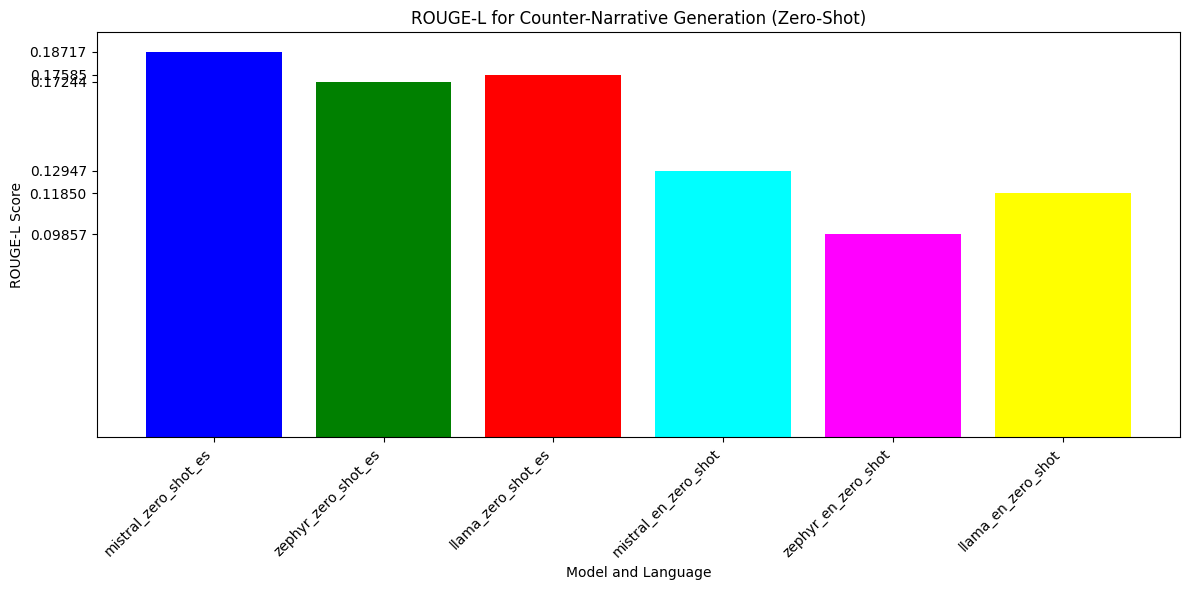

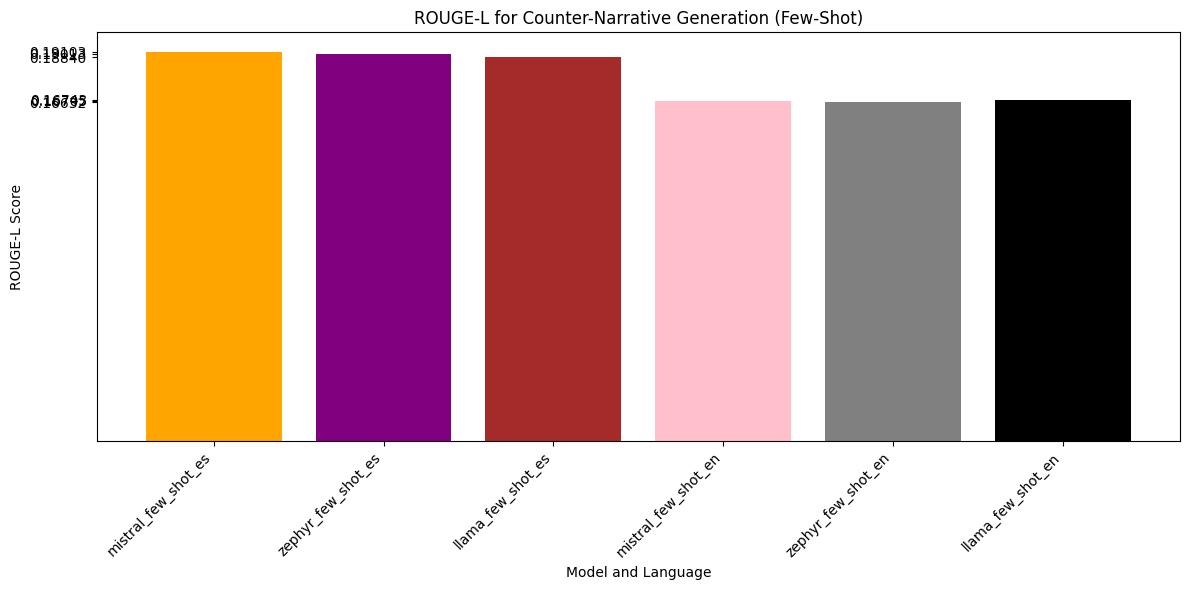

In [ ]:
# prompt: do it the same for RougeL
from rouge_score import rouge_scorer

# ... (Previous code for loading models, generating counter-narratives, etc.) ...

# 1. Store all generated counter-narratives in a dictionary (including English)
# 1. Store all generated counter-narratives in a dictionary (including English)
all_counter_narratives = {
    "mistral_zero_shot_es": mistral_counter_narratives,
    "zephyr_zero_shot_es": zephyr_counter_narratives,
    "llama_zero_shot_es": llama_counter_narratives,
    "mistral_few_shot_es": mistral_counter_narratives_few_shot,
    "zephyr_few_shot_es": zephyr_counter_narratives_few_shot,
    "llama_few_shot_es": llama_counter_narratives_few_shot,
    "mistral_en_zero_shot": mistral_counter_narratives_en,  # English counter-narratives
    "zephyr_en_zero_shot": zephyr_counter_narratives_en,    # English counter-narratives
    "llama_en_zero_shot": llama_counter_narratives_en,     # English counter-narratives
    "mistral_few_shot_en": mistral_counter_narratives_few_shot_en,
    "zephyr_few_shot_en": zephyr_counter_narratives_few_shot_en,
    "llama_few_shot_en": llama_counter_narratives_few_shot_en
}

# 2. Get reference counter-narratives from the datasets (Spanish and English)
reference_counter_narratives_es = data["Reference-counternarrative"].tolist()  # Spanish references
reference_counter_narratives_en = data_en["CN"].tolist()  # English references

# 3. Calculate ROUGE and store results for both languages
rouge_results = {}  # Dictionary to store ROUGE results
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

for model_name, predictions in all_counter_narratives.items():
    # Determine language and references
    if model_name.endswith("_es"):
        lang = "es"
        references = reference_counter_narratives_es[:len(predictions)]
    else:  # model_name.endswith("_en"):
        lang = "en"
        references = reference_counter_narratives_en[:len(predictions)]

    # Calculate ROUGE-L for each prediction and store the average
    rouge_scores = []
    for i in range(len(predictions)):
        score = scorer.score(references[i], predictions[i])
        rouge_scores.append(score['rougeL'].fmeasure)
    rouge_results[model_name] = sum(rouge_scores) / len(rouge_scores)  # Average ROUGE-L

# 4. Plot the ROUGE results (similar to BERTScore plot)
# Separate zero-shot and few-shot results
zero_shot_results = {k: v for k, v in rouge_results.items() if "zero_shot" in k}
few_shot_results = {k: v for k, v in rouge_results.items() if "few_shot" in k}

# Create bar plot for zero-shot results
plt.figure(figsize=(12, 6))
plt.bar(zero_shot_results.keys(), zero_shot_results.values(), color=['blue', 'green', 'red', 'cyan', 'magenta', 'yellow'])
plt.title('ROUGE-L for Counter-Narrative Generation (Zero-Shot)')
plt.xlabel('Model and Language')
plt.ylabel('ROUGE-L Score')
plt.xticks(rotation=45, ha='right')
plt.yticks(list(zero_shot_results.values()))  # Use values from zero_shot_results
plt.tight_layout()
plt.show()

# Create bar plot for few-shot results
plt.figure(figsize=(12, 6))
plt.bar(few_shot_results.keys(), few_shot_results.values(), color=['orange', 'purple', 'brown', 'pink', 'gray', 'black'])
plt.title('ROUGE-L for Counter-Narrative Generation (Few-Shot)')
plt.xlabel('Model and Language')
plt.ylabel('ROUGE-L Score')
plt.xticks(rotation=45, ha='right')
plt.yticks(list(few_shot_results.values()))  # Use values from zero_shot_results
plt.tight_layout()
plt.show()